In [1]:
# daum 사이트에서 뉴스정보를 읽어 텍스트 파일로 저장후 유사도 확인
# 형태소 분석, Word2Vec, 유사도 분석 ...
!pip install konlpy              # 한국어 형태소 분석기
!pip install gensim              # Word2Vec 등 텍스트 벡터화 라이브러리
!pip install koreanize_matplotlib  # matplotlib 한글 폰트 자동 설정

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 102.0 MB/s eta 0:00:00


In [10]:
import pandas as pd
from konlpy.tag import Okt
okt = Okt()   # 한국어 형태소 분석기 초기화

# 뉴스 텍스트 파일 읽기 (한 줄씩 리스트로 저장)
with open('daumnews.txt', 'r', encoding='utf-8') as f:
    lines = f.read().splitlines()

# print(lines)

# 명사만 추출하여 단어 빈도 딕셔너리 생성
word_freq = {}
for line in lines:
  # okt.pos() : 각 단어에 품사 태깅
  # tag == 'Noun' : 명사만 필터링
  # len(word) > 1 : 1글자 단어 제외 (의미 없는 단어 제거)
  nouns = [word for word, tag in okt.pos(line) if tag == 'Noun' and len(word) > 1]
  # print(nouns)
  for noun in nouns:
    word_freq[noun] = word_freq.get(noun, 0) + 1   # 등장할 때마다 카운트 +1

print(word_freq)

# 단어 건수별 내림차순 정렬해 DataFrame에 저장
# lambda dul:(-dul[1], dul[0]) : 빈도 내림차순, 같은 빈도면 단어 오름차순
sortData = sorted(word_freq.items(), key=lambda dul:(-dul[1], dul[0]))
print(sortData)
df = pd.DataFrame(sortData, columns=['단어', '빈도수'])
print(df.head(10))   # 180 rows x 2 columns

{'미래': 1, '기술': 4, '산업': 1, '막대': 1, '이익': 1, '양자컴퓨터': 2, '글로벌': 1, '투자': 7, '은행': 1, '번스타인': 1, '지난': 1, '고객': 1, '서한': 1, '양자': 7, '컴퓨팅': 1, '컴퓨터': 1, '역사': 1, '다음': 3, '단계': 1, '이정표': 1, '라며': 1, '오픈': 1, '엔비디아': 1, '인공': 1, '지능': 1, '랠리': 1, '먹거리': 1, '투자자': 2, '물음': 1, '제시': 1, '주목': 1, '비단': 1, '증권': 1, '트럼프': 2, '주도': 1, '베팅': 2, '무대': 1, '바로': 1, '중앙': 3, '일보': 2, '프리미엄': 1, '구독': 1, '서비스': 1, '플러스': 1, '지식': 1, '정보': 1, '인사이트': 1, '콘텐트': 1, '제공': 1, '오늘': 1, '추천': 1, '섹터': 1, '종목': 1, '소개': 1, '미국': 2, '상무부': 1, '기업': 3, '달러': 1, '규모': 1, '의향': 1, '체결': 1, '단순': 1, '보조금': 2, '지급': 2, '대가': 1, '일부': 1, '분도': 1, '취득': 1, '구조': 1, '정부': 2, '지난해': 1, '반도체': 1, '인텔': 2, '방식': 2, '지원': 1, '발판': 1, '삼은': 1, '주가': 1, '개월': 1, '사이': 1, '급등': 1, '선뜻': 1, '초전도': 1, '이온': 1, '트랩': 1, '자체': 1, '표준': 1, '자리': 1, '때문': 1, '경쟁': 1, '상장폐지': 1, '불안감': 1, '존재': 1, '출처': 1}
[('양자', 7), ('투자', 7), ('기술', 4), ('기업', 3), ('다음', 3), ('중앙', 3), ('미국', 2), ('방식', 2), ('베팅', 2), ('보조금', 2), ('양자컴퓨터', 2)

In [11]:
# 유사도 확인
# 원본 파일에서 명사, 동사 추출 후 Word2Vec 학습용 파일로 저장
with open('nlp2word_freq.txt', 'w', encoding='utf-8') as fi:
  for line in lines:
    # stem=True : 동사/형용사를 원형으로 통일 (먹었다 → 먹다)
    tokens = okt.pos(line, stem=True)
    # 명사(Noun)와 동사(Verb)만 추출, 1글자 제외
    words = [word for word, tag in tokens if tag in ['Noun', 'Verb'] and len(word) > 1]
    if words:
      fi.write(' '.join(words))   # 한 줄에 단어들을 공백으로 구분하여 저장
      fi.write('\n')

from gensim.models import word2vec

# LineSentence : 텍스트를 한 줄씩 읽어 단어 리스트로 변환 (메모리 효율적)
sentences = word2vec.LineSentence('nlp2word_freq.txt')
print(sentences)

# Word2Vec 모델 학습
model = word2vec.Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

print('양자컴퓨터 유사한 단어 출력')
print(model.wv.most_similar('양자컴퓨터'))   # 코사인 유사도 상위 10개 단어

print()
# 두 단어의 벡터를 더한 결과에 가장 가까운 단어
# positive : 더할 단어 벡터, negative : 뺄 단어 벡터
print(model.wv.most_similar(positive=['양자컴퓨터', '은행']))              # 양자컴퓨터 + 은행
print(model.wv.most_similar(positive=['양자컴퓨터', '은행'], negative=['기술']))  # 양자컴퓨터 + 은행 - 기술

양자컴퓨터 유사한 단어 출력
[('규모', 0.2134050875902176), ('콘텐트', 0.19195520877838135), ('붙이다', 0.1677180975675583), ('집다', 0.16737806797027588), ('양자', 0.16198600828647614), ('이온', 0.15680302679538727), ('체결', 0.15615591406822205), ('투자', 0.1551819145679474), ('반도체', 0.15063679218292236), ('망설이다', 0.14507156610488892)]

[('양자', 0.23901432752609253), ('투자자', 0.20932689309120178), ('투자', 0.20259787142276764), ('상무부', 0.19649484753608704), ('얻다', 0.194017693400383), ('보조금', 0.187769815325737), ('규모', 0.17501193284988403), ('종목', 0.1649724841117859), ('방식', 0.14136117696762085), ('자체', 0.1370309740304947)]
[('규모', 0.22329814732074738), ('트럼프', 0.20877070724964142), ('상무부', 0.1949535608291626), ('먹거리', 0.1885886788368225), ('투자', 0.17288647592067719), ('양자', 0.15665678679943085), ('얻다', 0.15470635890960693), ('투자자', 0.14734384417533875), ('지능', 0.14445534348487854), ('일부', 0.13857436180114746)]


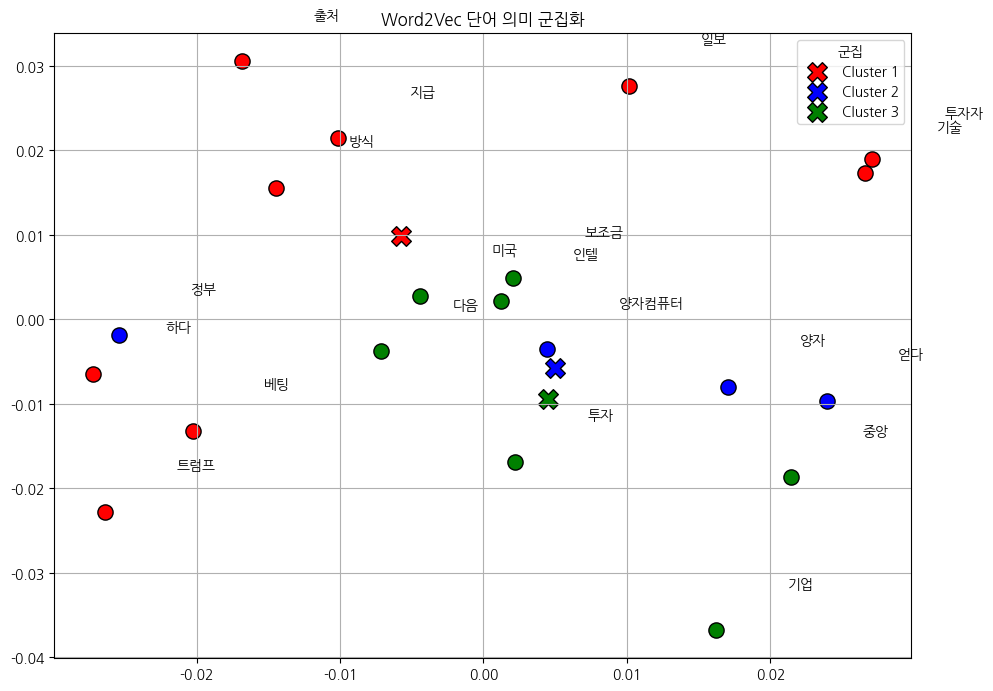

Cluster 1 번째 군집 소속 단어: 하다, 기술, 방식, 지급, 일보, 베팅, 트럼프, 투자자, 출처
Cluster 2 번째 군집 소속 단어: 양자, 정부, 얻다, 양자컴퓨터
Cluster 3 번째 군집 소속 단어: 투자, 기업, 중앙, 다음, 인텔, 보조금, 미국


In [12]:
import matplotlib.pyplot as plt
import koreanize_matplotlib        # 한글 폰트 자동 적용
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from collections import defaultdict

# Word2Vec에서 벡터 추출 (빈도 상위 20개 단어만 사용)
words = list(model.wv.index_to_key)[:20]          # 학습된 단어 중 상위 20개
filtered_words = [w for w in words if w in model.wv]   # 벡터가 존재하는 단어만 필터링
vectors = [model.wv[w] for w in filtered_words]         # 각 단어의 100차원 벡터

# KMeans 클러스터링
# n_clusters=3 : 3개 군집으로 분류
# random_state=42 : 재현성 확보 (같은 결과가 나오도록 시드 고정)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(vectors)   # 각 단어가 속하는 군집 번호 반환

# PCA로 100차원 → 2차원으로 축소
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)          # 단어 벡터 2D 변환
centers = pca.transform(kmeans.cluster_centers_)      # 군집 중심점도 동일하게 2D 변환

colors = ['red', 'blue', 'green', 'orange', 'purple']

plt.figure(figsize=(10, 7))

# 각 단어를 군집 색상으로 점 찍기
for i, word in enumerate(filtered_words):
    x, y = reduced_vectors[i]
    plt.scatter(x, y, color=colors[labels[i]], s=120, edgecolors='black')
    plt.text(x + 0.005, y + 0.005, word, fontsize=10)   # 점 옆에 단어 이름 표시

# 클러스터 중심점 (X 마커)
for i, (cx, cy) in enumerate(centers):
    plt.scatter(cx, cy, color=colors[i], s=200, marker='X', edgecolor='black', label=f'Cluster {i+1}')

plt.title('Word2Vec 단어 의미 군집화')
plt.legend(title='군집')
plt.grid(True)
plt.tight_layout()
plt.show()

# 군집별 단어 리스트 출력
cluster_words = defaultdict(list)
for word, label in zip(filtered_words, labels):
    cluster_words[label].append(word)

for cid, word_list in cluster_words.items():
    print(f'Cluster {cid+1} 번째 군집 소속 단어: {", ".join(word_list)}')

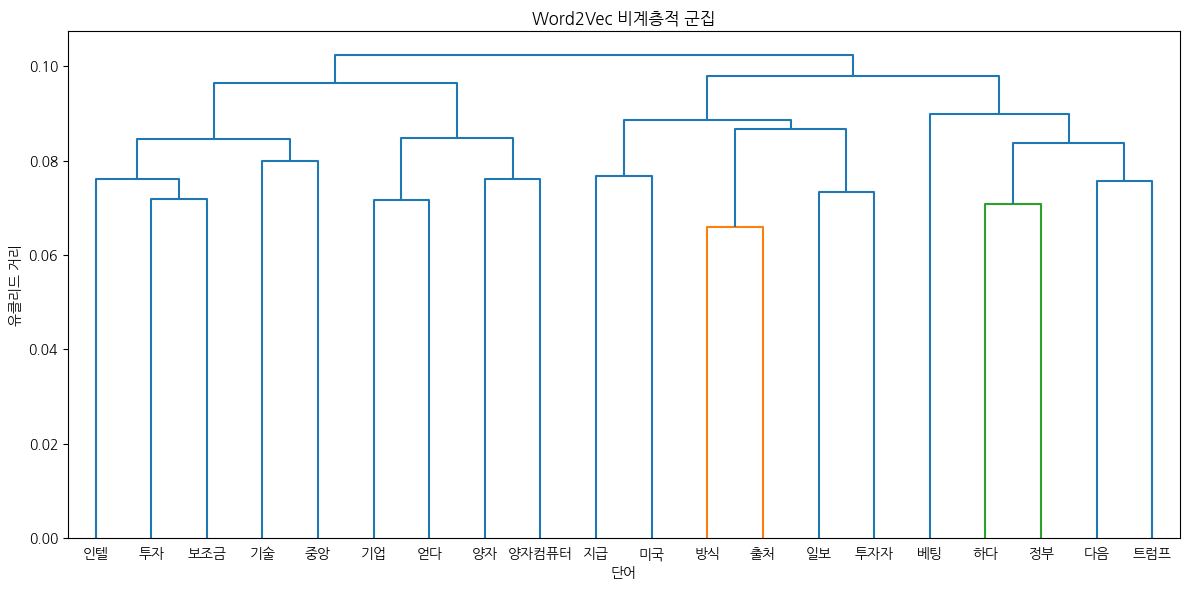

In [13]:
# 계층적 군집분석 - 덴드로그램
# KMeans(비계층적)과 달리 군집 수를 미리 정하지 않아도 됨
# Ward 연결법 : 군집 내 분산이 최소가 되도록 병합 (가장 일반적인 방식)
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

# 각 단어의 100차원 벡터를 numpy 배열로 변환
vectors = np.array([model.wv[word] for word in filtered_words])

# 연결 행렬 생성 : 단어 간 유클리드 거리 기반으로 병합 순서 계산
linkage_matrix = linkage(vectors, method='ward')

plt.figure(figsize=(12, 6))
# dendrogram : 계층적 군집 결과를 트리 구조로 시각화
# labels : x축에 표시할 단어 이름
# leaf_font_size : x축 단어 폰트 크기
dendrogram(linkage_matrix, labels=filtered_words, leaf_font_size=10)
plt.title('Word2Vec 비계층적 군집')   # 실제로는 계층적 군집 (덴드로그램)
plt.xlabel('단어')
plt.ylabel('유클리드 거리')           # Y축 = 두 군집 간 거리 (높을수록 더 다름)
plt.tight_layout()
plt.show()